Business Understanding
        ↓

Dataset Collection
        ↓

CSV Import
        ↓

Data Understanding
        ↓

Data Cleaning
        ↓

Missing Value Analysis
        ↓

Duplicate Analysis
        ↓

Outlier Analysis
        ↓

EDA
        ↓

Feature Engineering
        ↓

Customer-level Dataset
        ↓

Feature Selection
        ↓

Distribution Analysis
        ↓

Log Transformation
        ↓

Feature Scaling
        ↓

Correlation Analysis
        ↓

PCA
        ↓

Optimal K
        ↓

K-Means
        ↓

Cluster Evaluation
        ↓

Cluster Profiling
        ↓

Business Interpretation
        ↓

Final Customer Segmentation
        ↓

Save Model
        ↓

Save Clustered Dataset
        ↓
        
Deployment Pipeline

In [5]:
import warnings


warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from datetime import datetime


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


from sklearn.metrics import silhouette_score

import joblib

In [9]:

df = pd.read_csv(r"D:\ALL_IN_ONE\DATA\Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 200
Columns: 5


In [11]:
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


In [13]:
print(df.describe().T)

                        count    mean        std   min    25%    50%     75%  \
CustomerID              200.0  100.50  57.879185   1.0  50.75  100.5  150.25   
Age                     200.0   38.85  13.969007  18.0  28.75   36.0   49.00   
Annual Income (k$)      200.0   60.56  26.264721  15.0  41.50   61.5   78.00   
Spending Score (1-100)  200.0   50.20  25.823522   1.0  34.75   50.0   73.00   

                          max  
CustomerID              200.0  
Age                      70.0  
Annual Income (k$)      137.0  
Spending Score (1-100)   99.0  


In [15]:
print("Missing values:\n", df.isnull().sum().sort_values(ascending=False))

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [16]:
missing_percentage = (df.isnull().sum()/ len(df)) * 100

print(missing_percentage)

CustomerID                0.0
Gender                    0.0
Age                       0.0
Annual Income (k$)        0.0
Spending Score (1-100)    0.0
dtype: float64


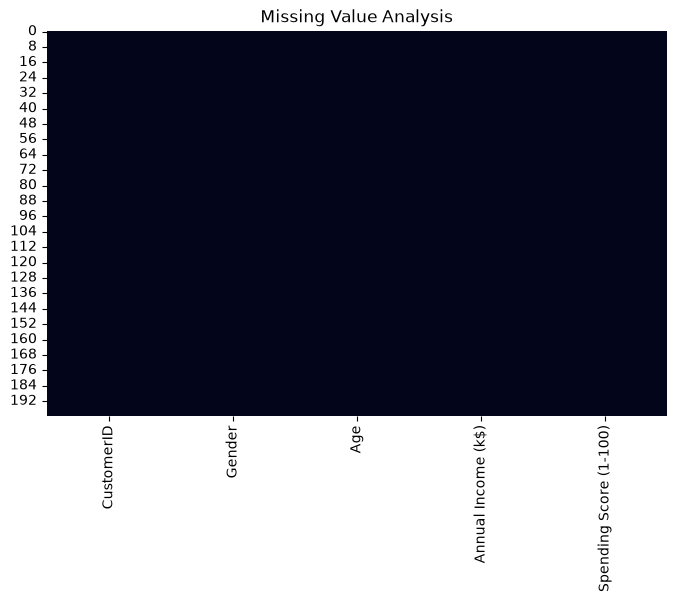

In [17]:
plt.figure(figsize=(8, 5))

sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Value Analysis")

plt.show()

In [18]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [19]:
print(df["Gender"].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [20]:
print(df["Gender"].value_counts())

Gender
Female    112
Male       88
Name: count, dtype: int64


In [21]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})


### Outlier Analysis

In [22]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=[object]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical features: []


In [23]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


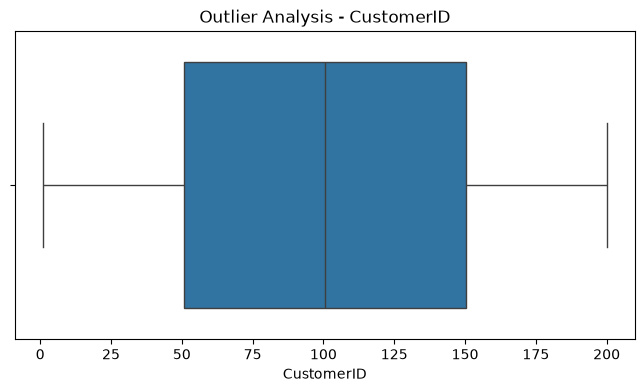

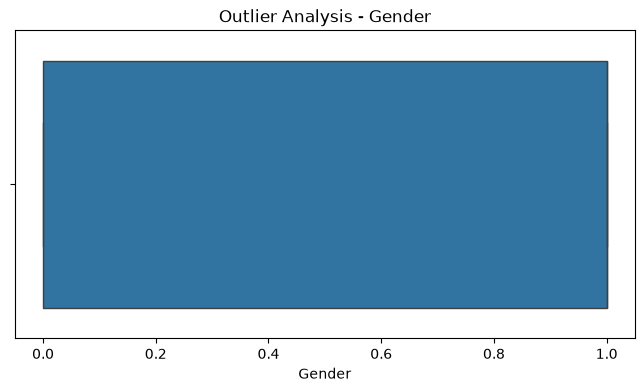

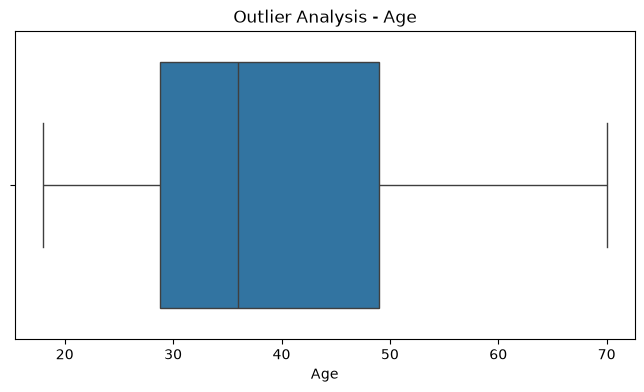

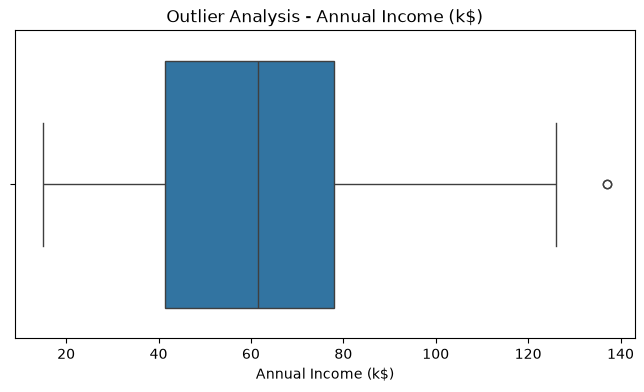

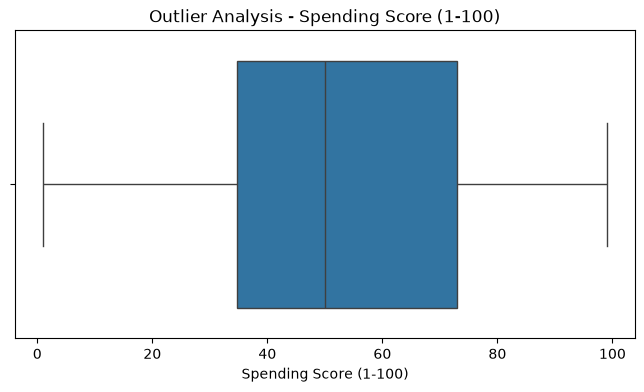

In [24]:
for column in numeric_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Outlier Analysis - {column}")

    plt.show()

### Outlier detection using IQR

In [25]:
for column in numeric_features:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers")

CustomerID: 0 outliers
Gender: 0 outliers
Age: 0 outliers
Annual Income (k$): 2 outliers
Spending Score (1-100): 0 outliers


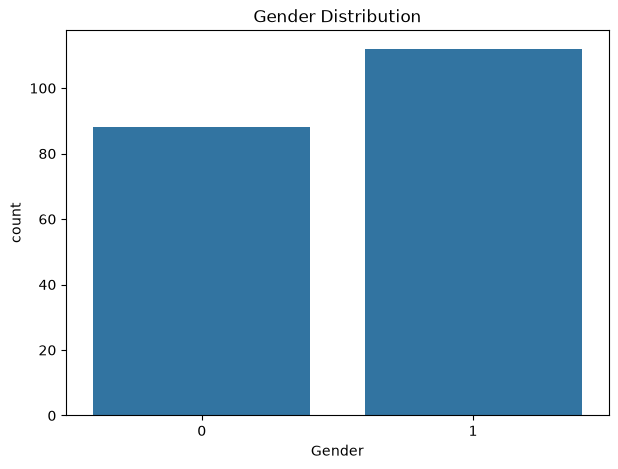

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df,x="Gender")

plt.title("Gender Distribution")

plt.show()

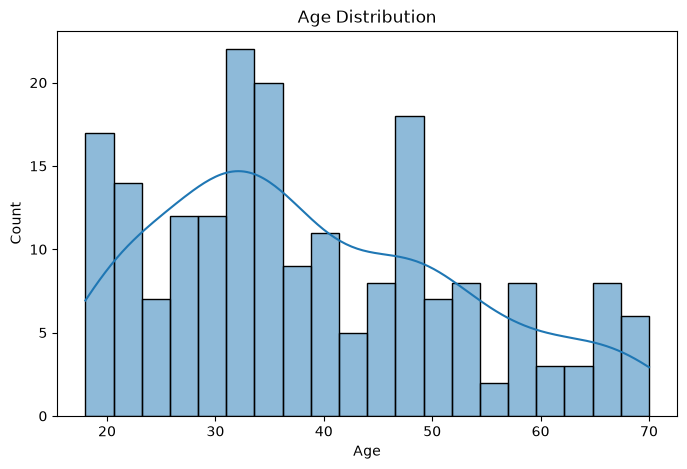

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df,x="Age",bins=20,kde=True)

plt.title("Age Distribution")

plt.show()

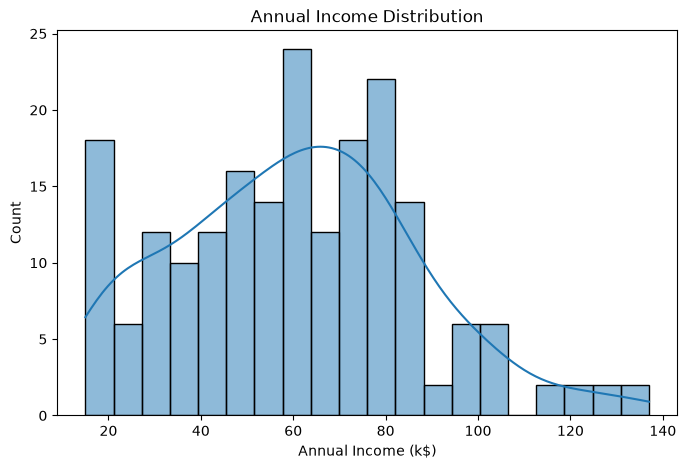

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")

plt.show()

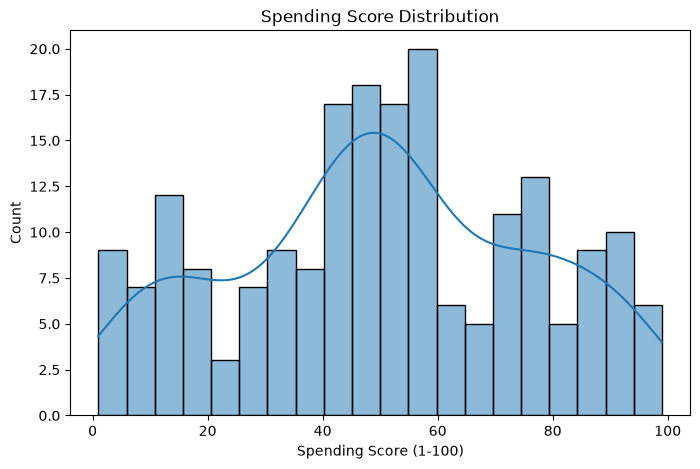

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")

plt.show()

In [30]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

features_with_gender = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Gender_encoded"
]



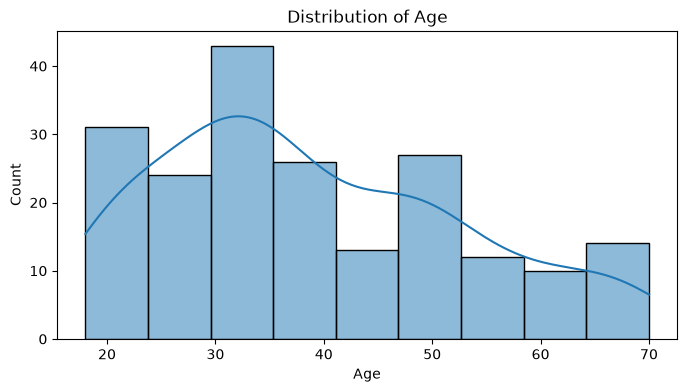

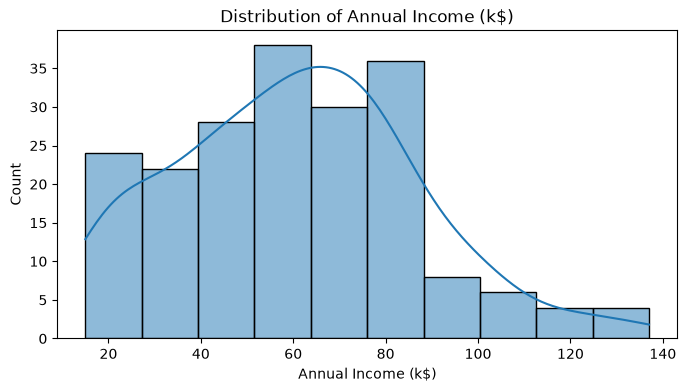

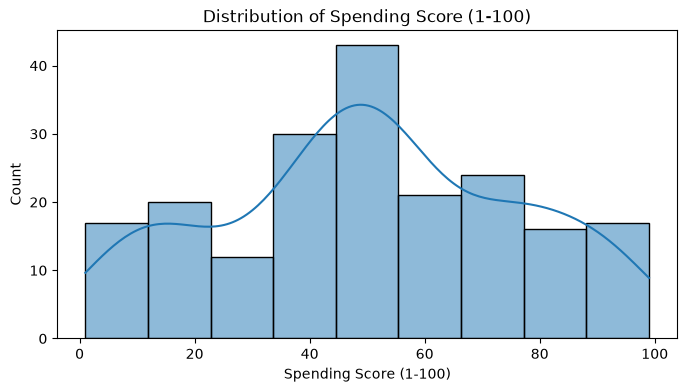

In [32]:
for column in features:

    plt.figure(figsize=(8, 4))

    sns.histplot(df[column],kde=True)

    plt.title(f"Distribution of {column}")

    plt.show()

In [33]:
print(df[features].skew())

Age                       0.485569
Annual Income (k$)        0.321843
Spending Score (1-100)   -0.047220
dtype: float64


In [34]:
df_log = df[features].copy()

for column in features:

    if df_log[column].min() >= 0:

        df_log[column] = np.log1p(
            df_log[column]
        )

### Feature Scaling

In [35]:
X = df[features].copy()

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled,columns=features)
X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [37]:
correlation = df[features].corr()

print(correlation)

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


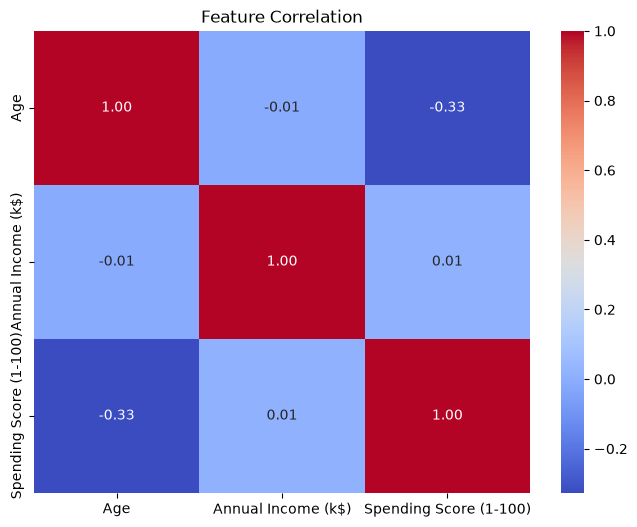

In [38]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [39]:
pca = PCA(n_components=2)

In [40]:
X_pca = pca.fit_transform(X_scaled)

In [41]:
pca_df = pd.DataFrame(X_pca,columns=["PC1", "PC2"])

In [42]:
print("Explained Variance:",pca.explained_variance_ratio_)

Explained Variance: [0.44266167 0.33308378]


In [43]:
print("Total Explained Variance:",pca.explained_variance_ratio_.sum())

Total Explained Variance: 0.7757454566976747


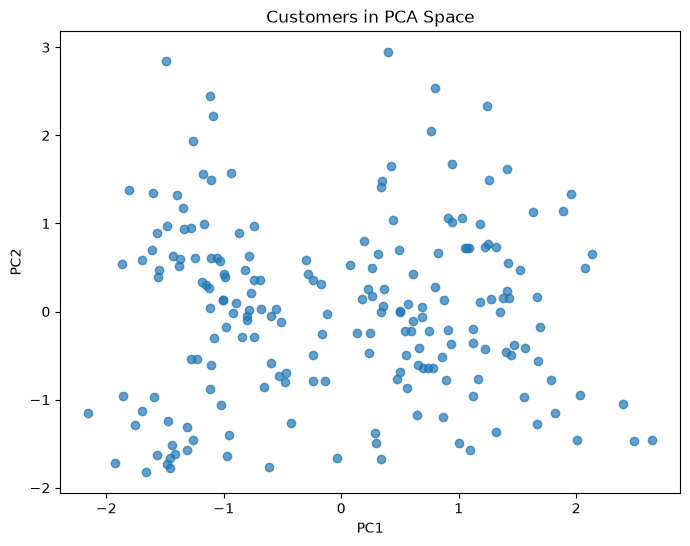

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Customers in PCA Space")

plt.show()

In [45]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

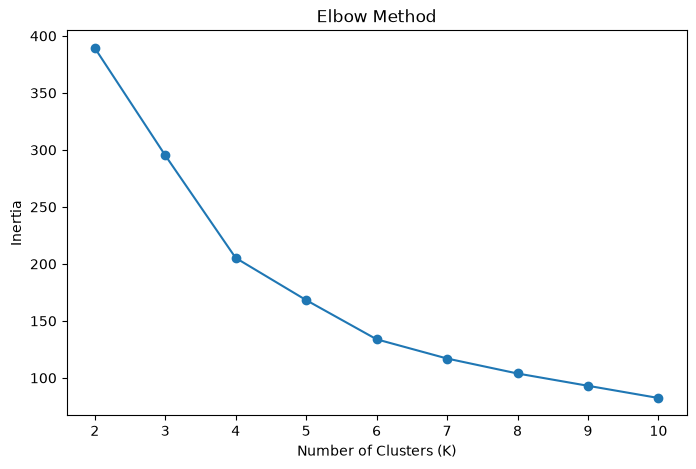

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(K_range,inertia,marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [47]:
silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score( X_scaled, labels)

    silhouette_scores.append(score)

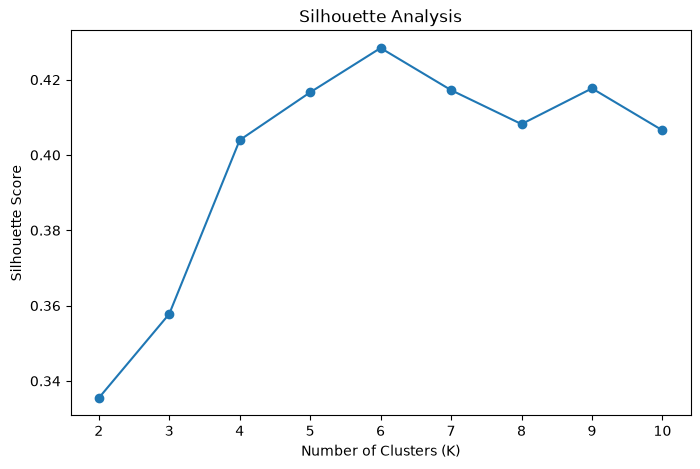

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

In [49]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k,random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

In [51]:
df["Cluster"] = cluster_labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,1
1,2,0,21,15,81,1
2,3,1,20,16,6,0
3,4,1,23,16,77,1
4,5,1,31,17,40,1


In [52]:
silhouette = silhouette_score(X_scaled,cluster_labels)

print("Silhouette Score:",round(silhouette, 4))

Silhouette Score: 0.4166


In [54]:
cluster_profile = (
    df
    .groupby("Cluster")[
        [
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ]
    .mean()
    .round(2)
)
print(cluster_profile)

           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        46.25               26.75                   18.35
1        25.19               41.09                   62.24
2        32.88               86.10                   81.53
3        39.87               86.10                   19.36
4        55.64               54.38                   48.85


In [55]:
cluster_size = (df["Cluster"].value_counts().sort_index())

print(cluster_size)

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


In [58]:
segment_names = {
    0: "Low Income Customers",
    1: "High Value Customers",
    2: "High Income Low Spending",
    3: "Moderate Customers",
    4: "Young High Spending Customers"
}




In [59]:
df["Segment"] = df["Cluster"].map(segment_names)
df[
    [
        "CustomerID",
        "Gender",
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)",
        "Cluster",
        "Segment"
    ]
].head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,0,19,15,39,1,High Value Customers
1,2,0,21,15,81,1,High Value Customers
2,3,1,20,16,6,0,Low Income Customers
3,4,1,23,16,77,1,High Value Customers
4,5,1,31,17,40,1,High Value Customers
5,6,1,22,17,76,1,High Value Customers
6,7,1,35,18,6,0,Low Income Customers
7,8,1,23,18,94,1,High Value Customers
8,9,0,64,19,3,0,Low Income Customers
9,10,1,30,19,72,1,High Value Customers


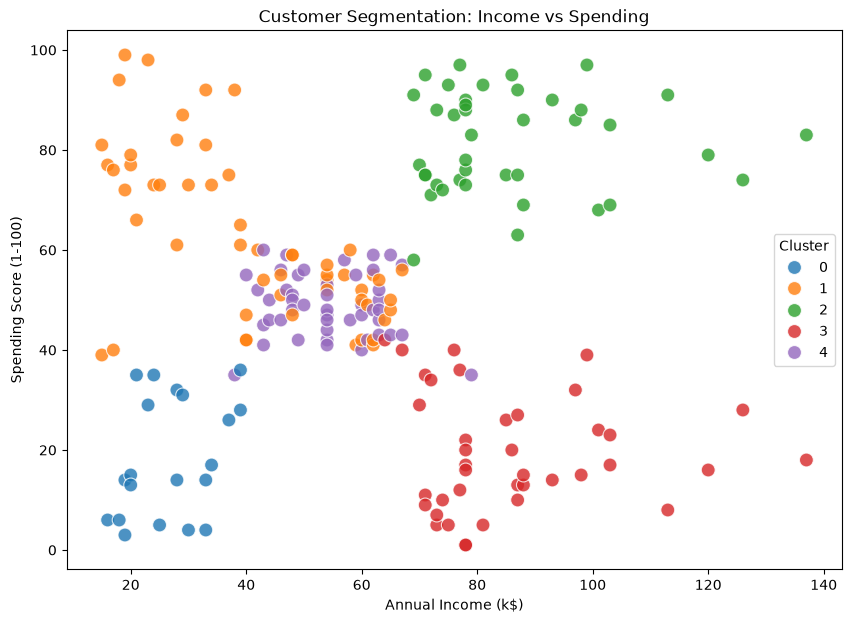

In [60]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=100,
    alpha=0.8
)

plt.title(
    "Customer Segmentation: Income vs Spending"
)

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.legend(
    title="Cluster"
)

plt.show()

In [61]:
pca_plot = pca_df.copy()

pca_plot["Cluster"] = cluster_labels

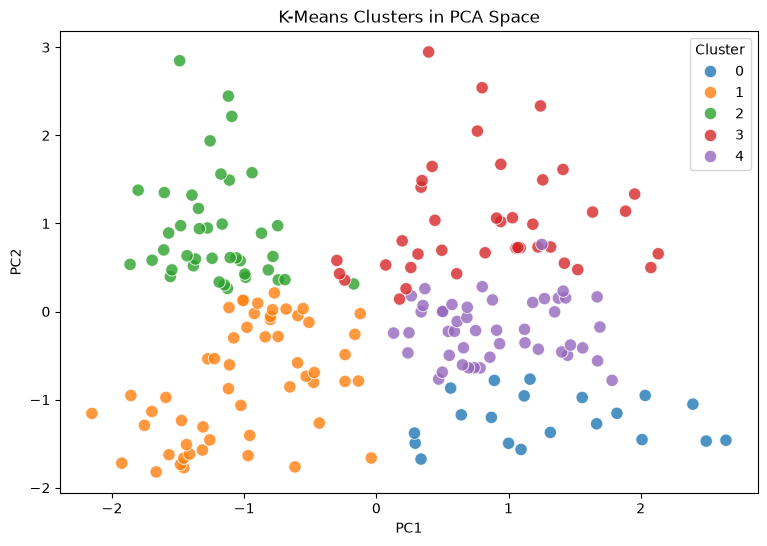

In [62]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=80,
    alpha=0.8
)

plt.title("K-Means Clusters in PCA Space")

plt.show()